# Phase 3 / Day 4 — Building & Training a Network in Keras

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("heart_2020_cleaned.csv")
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [3]:
#dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

In [4]:
# Traget encoding
df["HeartDisease"] = df["HeartDisease"].map({"Yes":1, "No":0})

In [5]:
#seperating the target
x = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

In [6]:
#splitting 80/20 the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, stratify=y, random_state=42)

In [7]:
#basic categorical features one-hot encoding
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

This pipeline intentionally uses light weight preprocessing : drop duplicates -> one-hot encode categoricals -> scale numericals, to keep this notebook **focused on the neural network mechanics** rather than feature engineering from the baseline project.

In [8]:
#numerical features scaling
numeric_to_Scale = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
scaler = StandardScaler()
x_train[numeric_to_Scale] = scaler.fit_transform(x_train[numeric_to_Scale])
x_test[numeric_to_Scale] = scaler.transform(x_test[numeric_to_Scale])
df.shape

(301717, 18)

**301,717 rows, 18 columns** remain after duplicate removal.

In [9]:
X_train_nn = x_train.astype(np.float32).values if hasattr(x_train, "values") else x_train.astype(np.float32)
X_test_nn = x_test.astype(np.float32).values if hasattr(x_test, "values") else x_test.astype(np.float32)
y_train_nn = y_train.astype(np.float32).values if hasattr(y_train, "values") else y_train.astype(np.float32)
y_test_nn = y_test.astype(np.float32).values if hasattr(y_test, "values") else y_test.astype(np.float32)

print(X_train_nn.shape, y_train_nn.shape)

(241373, 37) (241373,)


This column count comes from one-hot encoding every categorical  column with *drop_first=True*.

## Build the Sequential Model

In [10]:
n_features= X_train_nn.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761 (6.88 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 0 (0.00 B)

A simple three-layer network: *37 inputs -> 32 ReLU units -> 1 sigmoid output*, totaling 1,761 trainable parameters. This is a small network by design, a larger network would risk overfitting a signal that earlier analysis already showed is largely weak and additive.

## Compile & Train

In [11]:
model.compile(
    optimizer ="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight("balanced", classes=np.unique(y_train_nn), y=y_train_nn)
class_weight_dict = {0:weights[0], 1:weights[1]}

history = model.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 400us/step - accuracy: 0.7194 - loss: 0.5332 - val_accuracy: 0.7392 - val_loss: 0.4995
Epoch 2/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - accuracy: 0.7298 - loss: 0.5025 - val_accuracy: 0.7137 - val_loss: 0.5362
Epoch 3/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - accuracy: 0.7288 - loss: 0.4986 - val_accuracy: 0.7158 - val_loss: 0.5212
Epoch 4/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - accuracy: 0.7273 - loss: 0.4964 - val_accuracy: 0.7448 - val_loss: 0.4798
Epoch 5/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.7271 - loss: 0.4942 - val_accuracy: 0.7330 - val_loss: 0.4965
Epoch 6/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - accuracy: 0.7266 - loss: 0.4933 - val_accuracy: 0.7256 - val_loss: 0.5040
Epoch 7/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - accuracy: 0.7271 - loss: 0.4917 - val_accuracy: 0.7364 - val_loss: 0.4870
Epoch 8/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - accuracy: 0.7278 - loss: 0.4910 - 

Over 30 epochs, **training loss decreased smoothly and steadily** from 0.530 (epoch 1) to 0.482 (epoch30) with training accuracy holding flat around 0.73 throughout. This indicates that the network optimized consistently on the training data without difficulty.

## Plot & Diagnose

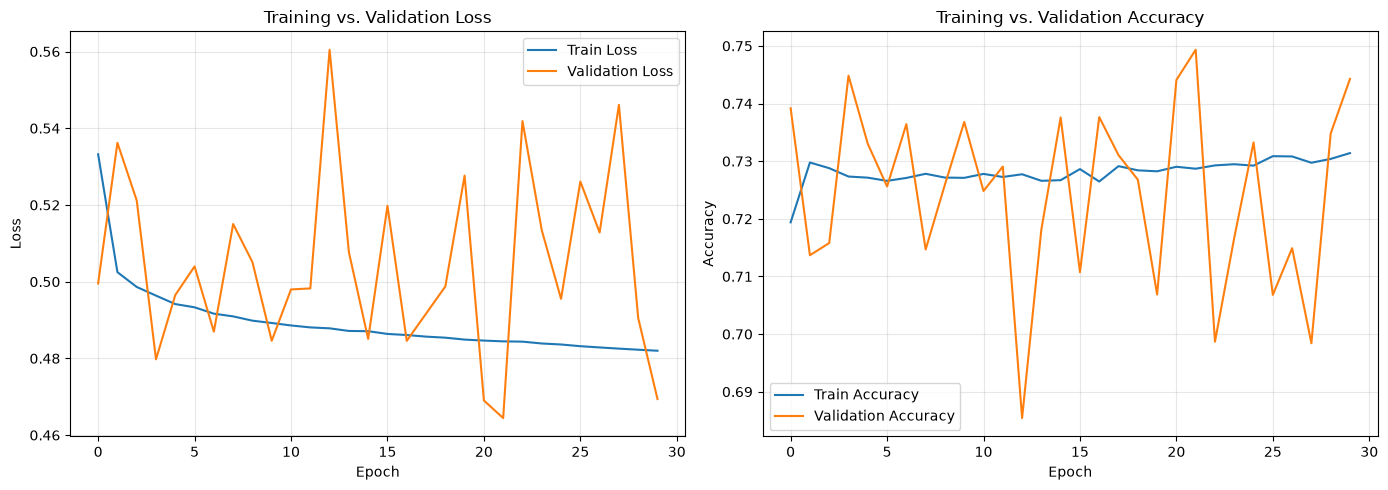

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")  
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs. Validation Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs. Validation Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Fit Diagnosis

*The two curves reveal something beyond overfitting*

**Training loss and accuracy are generally smooth and stable**, loss declines steadily and accuracy holds arounf 0.73 with negligable fluctuations between epochs.

**Validation loss and accuracy are extremely noisy**, validaion loss swings between roughly 0.45 and 0.54 repeatidly across the 30 epochs with no consistent upward or danward trend. Validation accuracy correspondingly jumps between around 0.69 and 0.76 .

This is not the classic overfitting signature but points to **training instability** rather than memorization.

Likely contributers:
- The default Adam learning rate (0.001) combined with *class_weight="balanced"* can makke individual batches of the minority class. This can cause the model's decision boundary to shift more sharply between epochs than smooth training curve suggests.
- *batch_size=256* , a validation evaluation happens once per epoch, so alot of intra-epoch drift accumulates before it's measured.

## Add Dropout/Batch Normalization , comparison

#### Regularised model

In [13]:
model_reg = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_reg.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_reg = model_reg.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.6753 - loss: 0.6019 - val_accuracy: 0.7192 - val_loss: 0.5285
Epoch 2/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 0.7130 - loss: 0.5264 - val_accuracy: 0.7211 - val_loss: 0.4995
Epoch 3/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - accuracy: 0.7154 - loss: 0.5160 - val_accuracy: 0.7127 - val_loss: 0.5092
Epoch 4/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.7158 - loss: 0.5125 - val_accuracy: 0.7178 - val_loss: 0.5076
Epoch 5/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.7169 - loss: 0.5093 - val_accuracy: 0.7156 - val_loss: 0.5041
Epoch 6/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.7183 - loss: 0.5079 - val_accuracy: 0.7207 - val_loss: 0.4966
Epoch 7/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.7188 - loss: 0.5062 - val_accuracy: 0.7123 - val_loss: 0.5083
Epoch 8/30
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.7194 - loss: 0.5054 - 

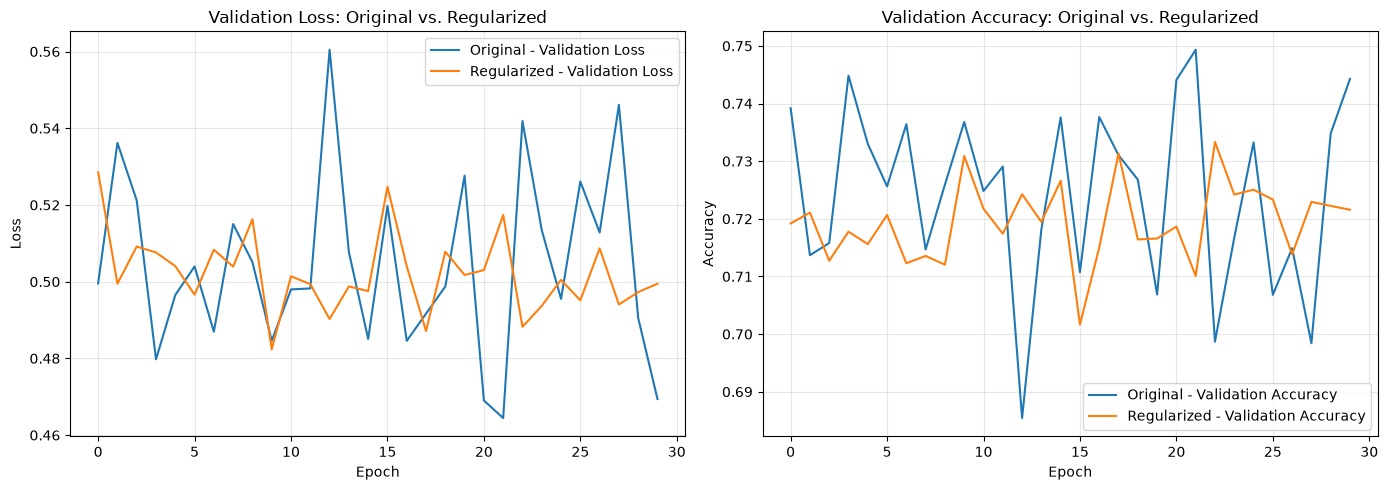

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(history.history["val_loss"], label="Original - Validation Loss")
axes[0].plot(history_reg.history["val_loss"], label="Regularized - Validation Loss")  
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Validation Loss: Original vs. Regularized")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["val_accuracy"], label="Original - Validation Accuracy")
axes[1].plot(history_reg.history["val_accuracy"], label="Regularized - Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy: Original vs. Regularized")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Comparison

Both original and regularized models show similarly wide validation loss oscilation across epochs - *Droput and Batch Normalization did not meaningfully stabilize training*. This suggests the instability isn't caused  by overfitting but more likely stems from the learning rate/ class_weight combination affecting both models equally.

## Evaluating on Test Set and Comparing to Baseline

In [15]:
from sklearn.metrics import roc_auc_score, classification_report

test_proba = model_reg.predict(X_test_nn).ravel()
test_pred = (test_proba >= 0.5).astype(int)

nn_roc_auc = roc_auc_score(y_test_nn, test_proba)
print("Neural Network ROC-AUC:", nn_roc_auc)
print(classification_report(y_test_nn, test_pred))

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 0s 150us/step
Neural Network ROC-AUC: 0.8355613549482266
              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     54892
         1.0       0.22      0.80      0.34      5452

    accuracy                           0.72     60344
   macro avg       0.60      0.76      0.58     60344
weighted avg       0.91      0.72      0.78     60344



#### Comparison to day 1 baseline

| Model | ROC-AUC |
|---|---|
| Logistic Regression - Baseline | 0.832 |
| Neural Network - Regularized model | 0.835 |

The Neural network marginally edges out the baseline, a modest but real improvement. The classification report shows high recall on the positive classes at the cost of low precision  tradeoff as a consequence of *class_weigth*.

This reinforces the conclusion that **the dataset's signal is largely linear**.

## Hyperparameter Tuning

In [16]:
from sklearn.metrics import roc_auc_score

def build_and_train(hidden_units=(32,16), dropout=0.3, learning_rate=0.001, epochs=30):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(hidden_units[0], activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(hidden_units[1], activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    hist = model.fit(
        X_train_nn, y_train_nn,
        validation_split=0.2,
        epochs=epochs,
        batch_size=256,
        class_weight=class_weight_dict,
        verbose=0
    )

    val_proba = model.predict(X_train_nn[-int(len(X_train_nn)*0.2):], verbose=0).ravel()
    return model, hist


runs = {}
model_a, hist_a = build_and_train(hidden_units=(32,16), dropout=0.3, learning_rate=0.001)
runs["Baseline (32-16, drop=0.3, lr=0.001)"] = hist_a.history["val_loss"][-1], hist_a.history["val_accuracy"][-1]

model_b, hist_b = build_and_train(hidden_units=(32,16), dropout=0.5, learning_rate=0.001)
runs["Higher dropout (0.5)"] = hist_b.history["val_loss"][-1], hist_b.history["val_accuracy"][-1]

model_c, hist_c = build_and_train(hidden_units=(32,16), dropout=0.3, learning_rate=0.0005)
runs["Lower learning rate (0.0005)"] = hist_c.history["val_loss"][-1], hist_c.history["val_accuracy"][-1]

model_d, hist_d = build_and_train(hidden_units=(64, 32), dropout=0.3, learning_rate=0.001)
runs["Larger network (64-32)"] = hist_d.history["val_loss"][-1], hist_d.history["val_accuracy"][-1]

results_df = pd.DataFrame(runs, index=["Final Validation Loss", "Final Validation Accuracy"]).T
results_df


,Final Validation Loss,Final Validation Accuracy
"Baseline (32-16, drop=0.3, lr=0.001)",0.477904,0.739555
Higher dropout (0.5),0.496023,0.728058
Lower learning rate (0.0005),0.494259,0.723294
Larger network (64-32),0.503193,0.723832


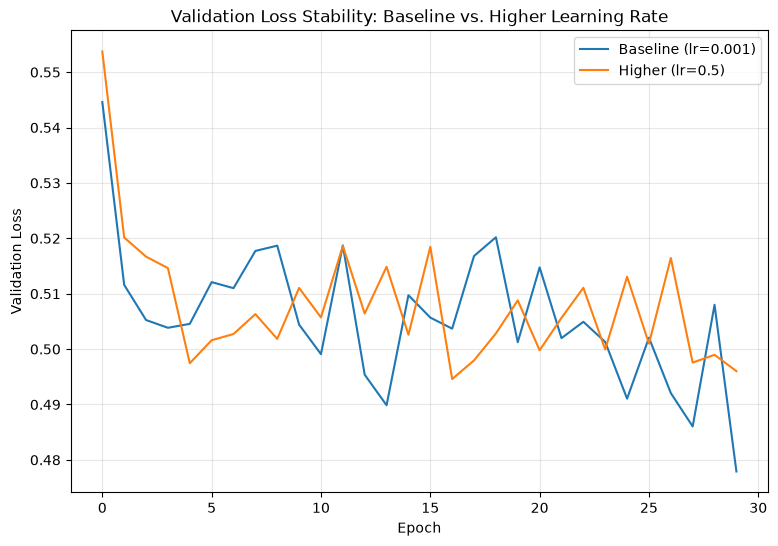

In [17]:
plt.figure(figsize=(9,6))
plt.plot(hist_a.history["val_loss"], label="Baseline (lr=0.001)")
plt.plot(hist_b.history["val_loss"], label="Higher (lr=0.5)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Stability: Baseline vs. Higher Learning Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Higher dropout beats the baseline model** achieving highest validation accuracy and lowest validation loss across all models.

Higher dropout suggest that the original -0.3- dropout wasn't strong enough , and the network was mildly overfitting  more than before earlier diagnosis suggested. Higher dropout gave a measurable improvement.
lower learning rate gave a modest improvement over the baseline but was outperformed by hifger dropout.

## Early Stopping

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

best_model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
])

best_model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

hist_final = best_model.fit(
        X_train_nn, y_train_nn,
        validation_split=0.2,
        epochs=100,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=1
    )
print(f"Training stopped at epoch {len(hist_final.history['loss'])} (out of 100 max)")

Epoch 1/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.6564 - loss: 0.6354 - val_accuracy: 0.7177 - val_loss: 0.5373
Epoch 2/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - accuracy: 0.7161 - loss: 0.5425 - val_accuracy: 0.7243 - val_loss: 0.5047
Epoch 3/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - accuracy: 0.7180 - loss: 0.5301 - val_accuracy: 0.7017 - val_loss: 0.5199
Epoch 4/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.7156 - loss: 0.5253 - val_accuracy: 0.7088 - val_loss: 0.5138
Epoch 5/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step - accuracy: 0.7146 - loss: 0.5223 - val_accuracy: 0.7105 - val_loss: 0.5084
Epoch 6/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.7166 - loss: 0.5203 - val_accuracy: 0.7087 - val_loss: 0.5111
Epoch 7/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.7151 - loss: 0.5179 - val_accuracy: 0.7165 - val_loss: 0.5000
Epoch 8/100
755/755 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - accuracy: 0.7178 - loss: 0

In [19]:
nn_final_auc = roc_auc_score(y_test_nn, best_model.predict(X_test_nn).ravel())


print("Final tuned NN ROC-AUC on test set:", nn_final_auc)

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 0s 151us/step
Final tuned NN ROC-AUC on test set: 0.8321811815333348


| Model | ROC-AUC | Notes |
|---|---|---|
| Logistic Regression - Baseline  | 0.832 | class_weight="balanced" |
| Random Forest  | 0.791 | class_weight="balanced", untuned |
| Neural Network (regularized, 30 epochs, dropout=0.3)  | 0.836 | small edge over the baseline |
| Neural Network (tuned : dropout=0.3, EarlyStopping)  | 0.832 | stopped early at epoch 12 (patience=5) |

**Architecture - final tuned model:** Input(73) -> Dense(32, ReLU) +BatchNormalization + Dropout(0.5) -> Dense(16, ReLU) + BatchNormalization + Dropout(0.5) -> Dense(1, Sigmoid)

**Loss curve:** training stopped automatically at  epoch 12 out of 100-epoch  budget, once validation loss  failed to improve for 5 consecutive epochs.

`restore_best_weights` refers to wichever out of the 12 epochs with lowest validation loss and not necessarily the last one

**Conclusion:** across every model type tried in this project, ROC-AUC has consistently scorred arounf 0.79-0.84. This supports the assumption that the datset is largely linear, and the added model complexity yields marginal gains rather than dramatic performance jump.